In [15]:
import json
import requests
import pandas as pd

# Charger les données
base_url = "https://api-base-fastapi-mpt-dkhjb0cydga2aydc.canadacentral-01.azurewebsites.net"
api_key = ""
with open('../api.json', 'r') as file:
    api_key = json.load(file)["GH_API_KEY"]

def get_call(paths,url=base_url, params=None, header=None):
    url = f"{base_url}/{paths}"
    response = requests.get(url, params=params, headers=header)
    if response.status_code == 200:
        return response.json()
    elif response.status_code == 403:
        print("La patience est d'or. Enculé")
        response = requests.get(url, params=params, headers=header)
        return response.json()
    else:
        print(f"Error: {response.status_code} - {response.json().get('message', 'Unknown error')}")
        return None
repositories = get_call(paths="show_data",params={"page_size":10000,"page":1})

In [16]:
df = pd.DataFrame(repositories['data'])
df.to_pickle("repositories_data.pkl")
# df = df['language'].value_counts()[df['language'].value_counts()>10]

In [1]:
import pandas as pd
df = pd.read_pickle("repositories_data.pkl")
len(df)

10000

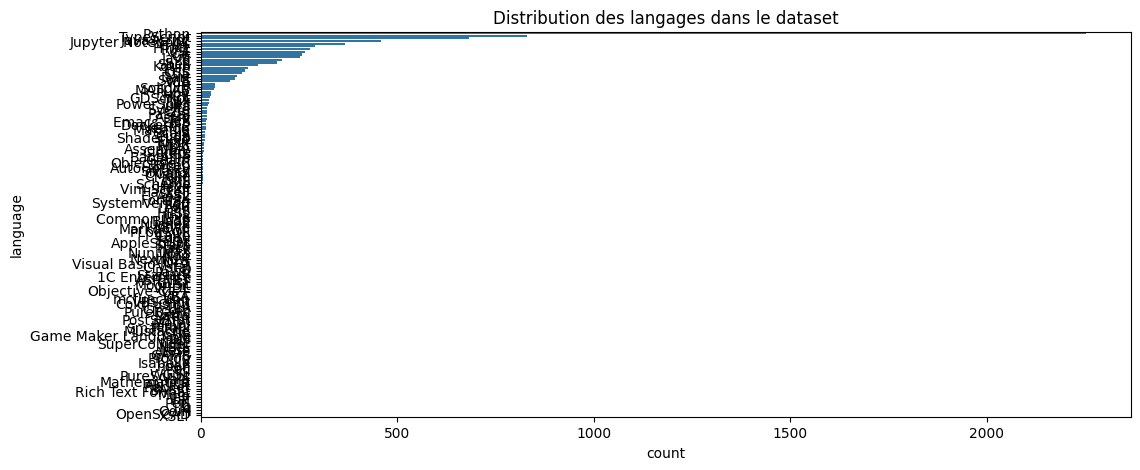

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.countplot(y=df["language"], order=df["language"].value_counts().index)
plt.title("Distribution des langages dans le dataset")
plt.show()

In [ ]:
from train import train_log
acc = train_log(df,model_name="random_forest",epochs=10, batch_size=256)
print(f"Modèle entraîné avec une accuracy de {acc}")


📈 Entraînement des epochs:   0%|          | 0/10 [00:00<?, ?it/s]


🔄 Epoch 1/10...


📈 Entraînement des epochs:  10%|█         | 1/10 [00:00<00:01,  4.56it/s]

🎯 Accuracy: 0.1924

🔄 Epoch 2/10...


📈 Entraînement des epochs:  20%|██        | 2/10 [00:00<00:01,  4.61it/s]

...

📈 Entraînement des epochs:  90%|█████████ | 9/10 [00:02<00:00,  4.36it/s]

🎯 Accuracy: 0.1911

🔄 Epoch 10/10...


📈 Entraînement des epochs: 100%|██████████| 10/10 [00:02<00:00,  4.40it/s]

🎯 Accuracy: 0.1863



2025/02/26 23:40:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'random_forest' already exists. Creating a new version of this model...
